<a href="https://colab.research.google.com/github/lord-of-the-strings/Data-Science/blob/main/02_inear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder/master/data/gapminder-FiveYearData.csv"
df = pd.read_csv(url)

In [2]:
df.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [3]:
print(df.shape)

(1704, 6)


In [4]:
data07=df[df['year']==2007]
data07.head()

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640


In [9]:
asia_data=df[df['continent']=='Asia']
asia_trends=asia_data.groupby('year')['lifeExp'].mean()
print(asia_trends)

year
1952    46.314394
1957    49.318544
1962    51.563223
1967    54.663640
1972    57.319269
1977    59.610556
1982    62.617939
1987    64.851182
1992    66.537212
1997    68.020515
2002    69.233879
2007    70.728485
Name: lifeExp, dtype: float64


In [11]:
gdp_trends = asia_data.groupby('year')['gdpPercap'].mean()
print(gdp_trends)

year
1952     5195.484004
1957     5787.732940
1962     5729.369625
1967     5971.173374
1972     8187.468699
1977     7791.314020
1982     7434.135157
1987     7608.226508
1992     8639.690248
1997     9834.093295
2002    10174.090397
2007    12473.026870
Name: gdpPercap, dtype: float64


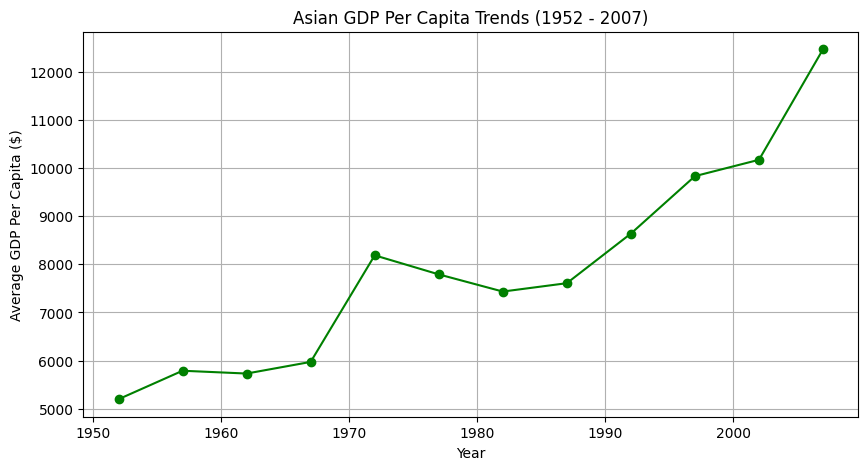

In [13]:
import matplotlib.pyplot as plt
gdp_trends.plot(kind='line', marker='o', color='green', figsize=(10, 5))
plt.title("Asian GDP Per Capita Trends (1952 - 2007)")
plt.xlabel("Year")
plt.ylabel("Average GDP Per Capita ($)")
plt.grid(True)
plt.show()

In [15]:
asia07=data07[data07['continent']=='Asia']
richest_asia_2007 = asia07.sort_values(by='gdpPercap', ascending=False)
richest_asia_2007.head(10)

,country,year,pop,continent,lifeExp,gdpPercap
863,Kuwait,2007,2505559.0,Asia,77.588,47306.98978
1367,Singapore,2007,4553009.0,Asia,79.972,47143.17964
671,Hong Kong China,2007,6980412.0,Asia,82.208,39724.97867
803,Japan,2007,127467972.0,Asia,82.603,31656.06806
95,Bahrain,2007,708573.0,Asia,75.635,29796.04834
1511,Taiwan,2007,23174294.0,Asia,78.400,28718.27684
767,Israel,2007,6426679.0,Asia,80.745,25523.27710
851,Korea Rep.,2007,49044790.0,Asia,78.623,23348.13973
1163,Oman,2007,3204897.0,Asia,75.640,22316.19287
1319,Saudi Arabia,2007,27601038.0,Asia,72.777,21654.83194


In [18]:
from sklearn.linear_model import LinearRegression
x=asia07[['gdpPercap']]
y=asia07[['lifeExp']]
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [20]:
print(f"Model Slope (m): {model.coef_[0]}")
print(f"Model Intercept (b): {model.intercept_}")

Model Slope (m): [0.00038784]
Model Intercept (b): [65.89093338]


In [25]:
#let's make a new country in Asia
new_gdp=pd.DataFrame([[10000]], columns=['gdpPercap'])
predicted_life_exp = model.predict(new_gdp)
print(f"For a country with a $10,000 GDP per capita, the model predicts a life expectancy of: {predicted_life_exp[0][0]:.1f} years old.")

For a country with a $10,000 GDP per capita, the model predicts a life expectancy of: 69.8 years old.


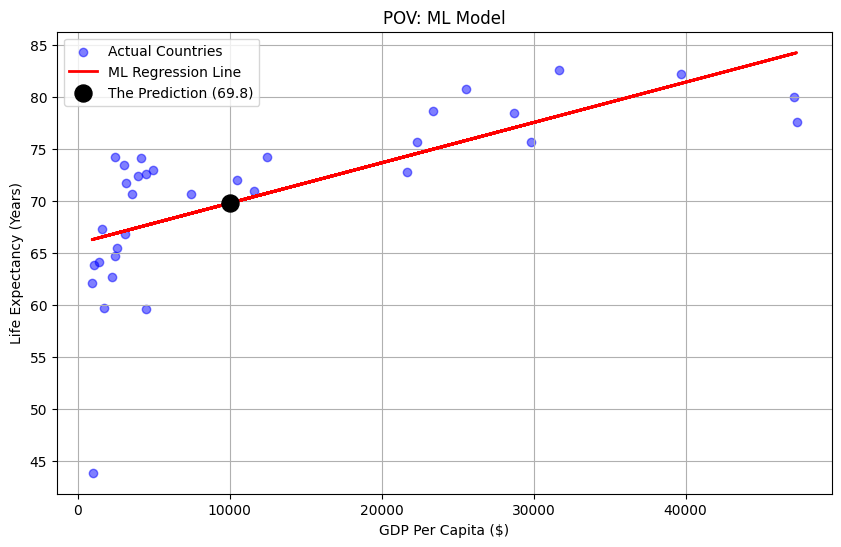

In [28]:
plt.figure(figsize=(10, 6))
X = asia07[['gdpPercap']]
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Countries')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='ML Regression Line')
plt.scatter([[10000]], [69.8], color='black', s=150, zorder=5, label='The Prediction (69.8)')
plt.title("POV: ML Model")
plt.xlabel("GDP Per Capita ($)")
plt.ylabel("Life Expectancy (Years)")
plt.legend()
plt.grid(True)
plt.show()